### 1. IMPORT LIBRARIES


In [23]:

import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


### 2. LOAD DATA

In [24]:

# Prefer local dataset if present
data_path = Path("Tweets.csv")
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at {data_path.resolve()}")

df = pd.read_csv(data_path)

# Clean column names
df.columns = df.columns.str.strip().str.lower()
print("Columns:", df.columns)

df.head()


Columns: Index(['textid', 'text', 'selected_text', 'sentiment'], dtype='object')


,textid,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


### 3. PREPROCESS DATA

In [25]:
TEXT_COL = "text" if "text" in df.columns else "selected_text"
LABEL_COL = "sentiment"

def prepare_split(dataframe, text_col, label_col, sample_limit=800, seed=42):
    subset = dataframe[[text_col, label_col]].dropna().copy()
    subset[text_col] = subset[text_col].astype(str).str.strip()
    subset[label_col] = subset[label_col].astype(str).str.lower().str.strip()

    if sample_limit is not None:
        sample_size = min(sample_limit, len(subset))
        subset = subset.sample(sample_size, random_state=seed).reset_index(drop=True)

    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    unknown = sorted(set(subset[label_col]) - set(label_map))
    if unknown:
        raise ValueError(f"Unexpected sentiment labels: {unknown}")

    texts = subset[text_col].tolist()
    labels = [label_map[x] for x in subset[label_col]]

    train_texts, val_texts, train_labels, val_labels = train_test_split(
        texts,
        labels,
        test_size=0.2,
        random_state=seed,
        stratify=labels,
    )
    return train_texts, val_texts, train_labels, val_labels, label_map

train_texts, val_texts, train_labels, val_labels, label_map = prepare_split(
    df,
    TEXT_COL,
    LABEL_COL,
    sample_limit=800,
    seed=42,
 )


### 4. TOKENIZATION

In [26]:

MAX_LEN = 40
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def encode_texts(texts, tok, max_len):
    return tok(
        texts,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt",
    )

train_encodings = encode_texts(train_texts, tokenizer, MAX_LEN)
val_encodings = encode_texts(val_texts, tokenizer, MAX_LEN)


### 5. DATASET CLASS

In [27]:

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)


### 6. DATALOADER

In [28]:

BATCH_SIZE = 32
FREEZE_ENCODER = True

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=0)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3,
    output_attentions=True,
)

if FREEZE_ENCODER:
    for param in model.bert.parameters():
        param.requires_grad = False

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 8. TRAINING LOOP

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Running on:", device)


Running on: cpu


Epoch 1 | Train Loss: 1.1154 | Val Acc: 0.3688 | Val F1: 0.2083
Epoch 2 | Train Loss: 1.1054 | Val Acc: 0.3688 | Val F1: 0.2073
Epoch 3 | Train Loss: 1.1043 | Val Acc: 0.3812 | Val F1: 0.2234

Validation Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        45
     neutral       0.39      0.98      0.56        61
    positive       0.25      0.02      0.03        54

    accuracy                           0.38       160
   macro avg       0.21      0.33      0.20       160
weighted avg       0.23      0.38      0.22       160



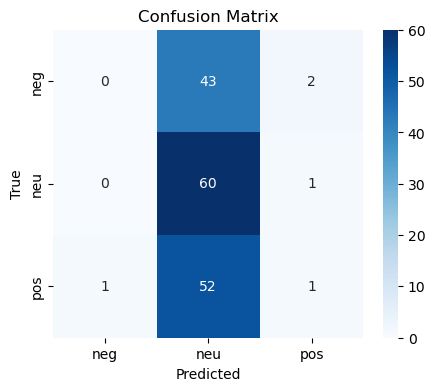

In [30]:

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)

def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            targets = batch.pop("labels")
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(targets.cpu().tolist())
    return all_targets, all_preds

EPOCHS = 3
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    all_targets, all_preds = evaluate(model, val_loader, device)
    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, average="weighted")
    print(f"Epoch {epoch + 1} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

print("\nValidation Report:")
print(classification_report(all_targets, all_preds, target_names=["negative", "neutral", "positive"]))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["neg", "neu", "pos"], yticklabels=["neg", "neu", "pos"])
plt.title("Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()


### 9. ATTENTION VISUALIZATION

In [31]:

def visualize_attention(text, layer=-1, head=0):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions
    attention = attentions[layer][0][head].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    plt.figure(figsize=(10, 8))
    sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title("Attention Heatmap")
    plt.xticks(rotation=90)
    plt.show()


### 10. PREDICTION FUNCTION

In [32]:

label_names = {0: "negative", 1: "neutral", 2: "positive"}

def predict(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()
    print("Text:", text)
    print("Predicted Sentiment:", label_names[pred])
    return label_names[pred]


### 11. TEST

Text: Service was slow but the staff were polite
Predicted Sentiment: neutral


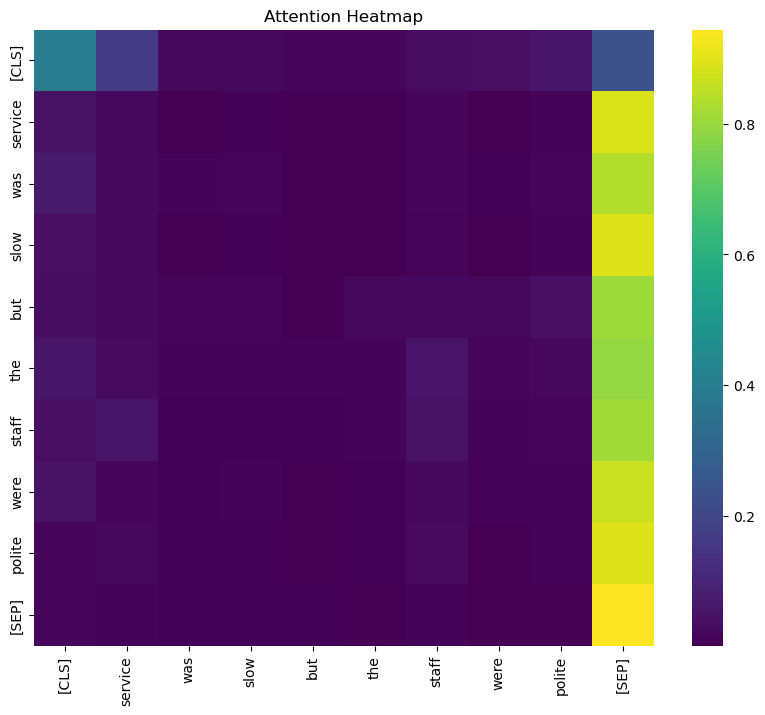

In [34]:

sample_texts = [
    "Service was slow but the staff were polite"
]

for text in sample_texts:
    predict(text)

visualize_attention(sample_texts[0])
